In [69]:
from astroML.datasets import generate_mu_z
from matplotlib import pyplot as plt
import numpy as np
import sklearn
from sklearn.linear_model import LinearRegression
from astroML.linear_model import PolynomialRegression
from astroML.linear_model import BasisFunctionRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import learning_curve
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from functools import partial
from astroML.linear_model.linear_regression import gaussian_basis
from astroML.linear_model import BasisFunctionRegression
from astroML.linear_model import NadarayaWatson
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel, RationalQuadratic
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KernelDensity
from scipy.integrate import quad
import emcee
import corner
from astropy.cosmology import FlatLambdaCDM
import dynesty
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc


SUPERNOVA DISTANCES AND REDSHIFT (PART 2)

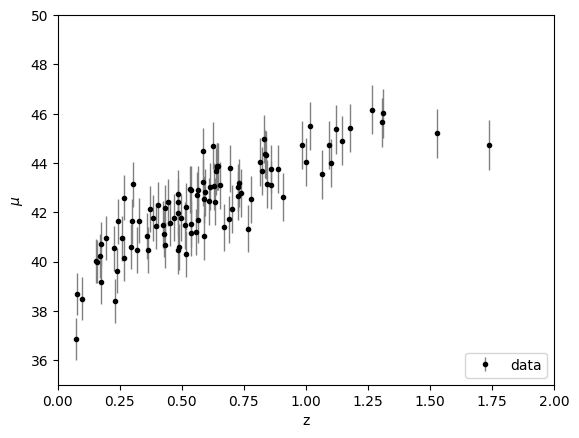

In [38]:
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

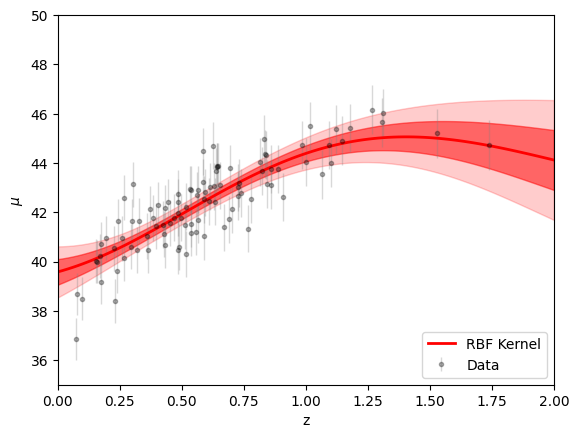

In [39]:
# Use GPR to fit the data and plot the results studying the effect of different parameters values.
# I will use RBF (radial basis function as suggested in the lecture)
X = z_sample.reshape(-1, 1)
Y = mu_sample
dY = dmu
z_fit = np.linspace(0, 2, 100).reshape(-1, 1)

# RBF kernel with different length scales 
kernel = RBF(10, (1e-2, 1e2))
gp_RBF = GaussianProcessRegressor(kernel=kernel, alpha=dY ** 2, normalize_y=True)
gp_RBF.fit(X, Y)
mu_RBF, std_RBF = gp_RBF.predict(z_fit, return_std=True)    
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, alpha=0.3, label='Data')
plt.plot(z_fit, mu_RBF, color='r', lw=2, label='RBF Kernel')
plt.fill_between(z_fit.flatten(), mu_RBF - std_RBF, mu_RBF + std_RBF, color='r', alpha=0.5)
plt.fill_between(z_fit.flatten(), mu_RBF - 2*std_RBF, mu_RBF + 2*std_RBF, color='r', alpha=0.2)
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);    
plt.show()

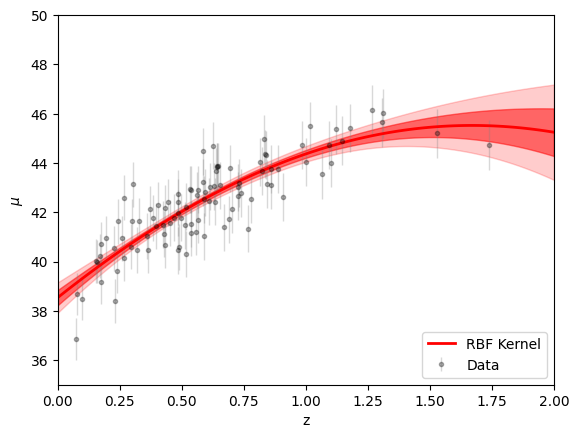

In [40]:
# RBF struggles to fit since assumes that the variance for the max data is 1.0 (even if normalize_y is True) expecially for low z data
# RBF * ConstantKernel 
X = z_sample.reshape(-1, 1)
Y = mu_sample
dY = dmu
z_fit = np.linspace(0, 2, 100).reshape(-1, 1)

# RBF kernel with different length scales 
kernel = RBF(10, (1e-2, 1e2)) * ConstantKernel(1, (1e-3, 1e3))
gp_RBF = GaussianProcessRegressor(kernel=kernel, alpha=dY ** 2)
gp_RBF.fit(X, Y)
mu_RBF, std_RBF = gp_RBF.predict(z_fit, return_std=True)    
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, alpha=0.3, label='Data')
plt.plot(z_fit, mu_RBF, color='r', lw=2, label='RBF Kernel')
plt.fill_between(z_fit.flatten(), mu_RBF - std_RBF, mu_RBF + std_RBF, color='r', alpha=0.5)
plt.fill_between(z_fit.flatten(), mu_RBF - 2*std_RBF, mu_RBF + 2*std_RBF, color='r', alpha=0.2)
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);    
plt.show()

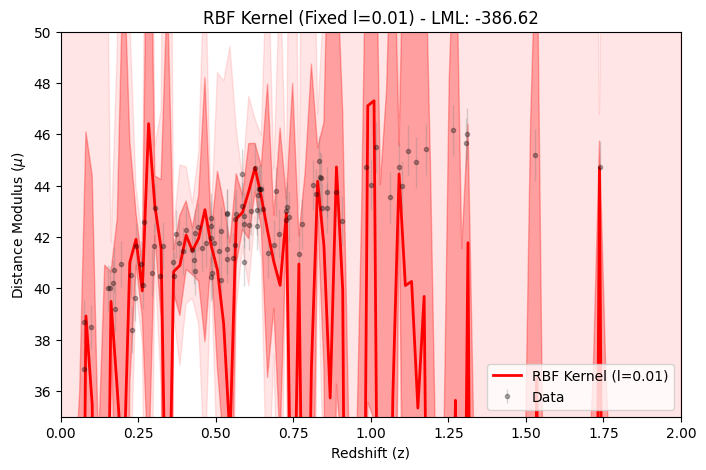

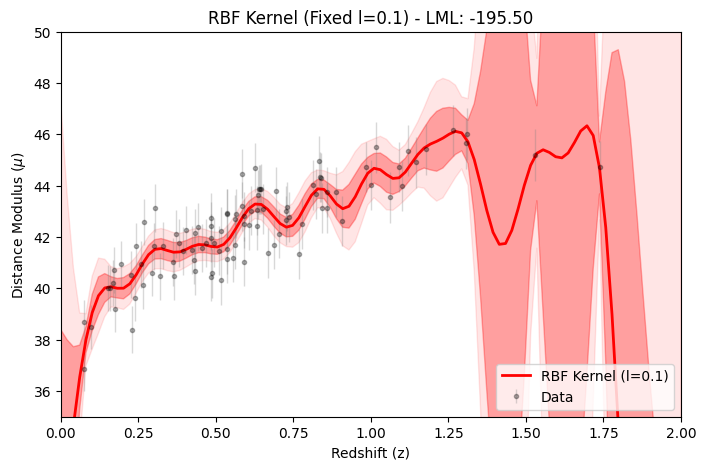

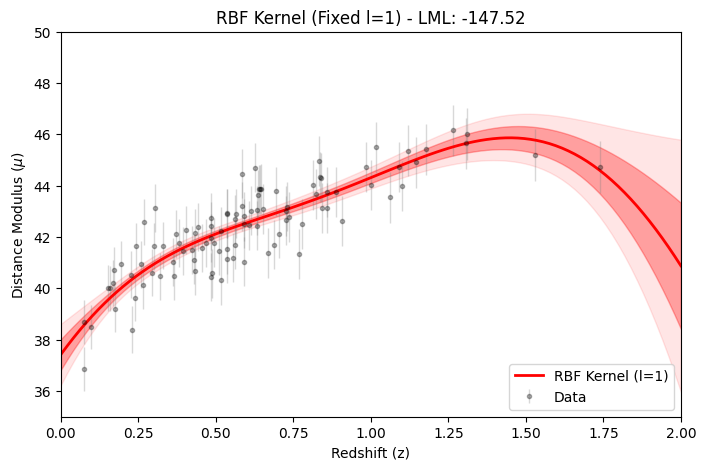

/Users/tommasogrisetti/Desktop/università/Magistrale/Astrostatistic and Machine Learning/astrostatistics_bicocca_2025-main/.venv/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


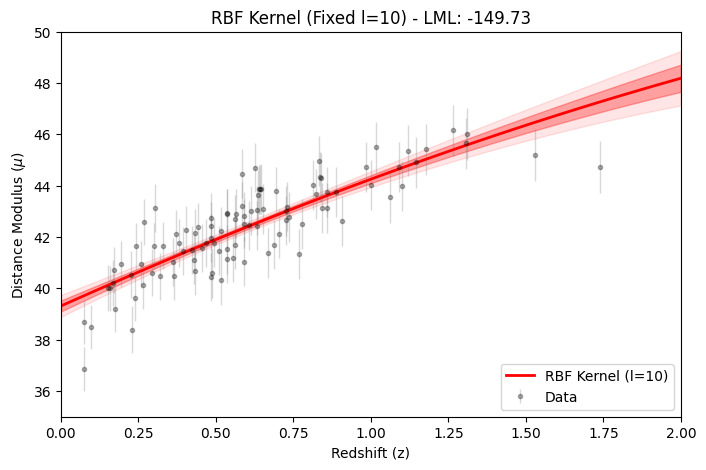

In [41]:
# Play with the parameters of the kernel and see how the fit changes. 
# Try to find the best fit by hand. 
l_values = [0.01, 0.1, 1, 10]

for l in l_values: 
    # I add length_scale_bounds = "fixed" to stop the auto-optimizer
    fixed_kernel =RBF(length_scale=l, length_scale_bounds="fixed") * ConstantKernel(1, (1e-3, 1e3))
    
    # Remember that alpha should be the variance (error squared)
    gp_RBF = GaussianProcessRegressor(kernel=fixed_kernel, alpha=dY**2)
    gp_RBF.fit(X, Y)
    
    mu_RBF, std_RBF = gp_RBF.predict(z_fit, return_std=True)    
    lml_score = gp_RBF.log_marginal_likelihood_value_

    plt.figure(figsize=(8, 5))
    plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, alpha=0.3, label='Data')
    plt.title(f"RBF Kernel (Fixed l={l}) - LML: {lml_score:.2f}")
    plt.plot(z_fit, mu_RBF, lw=2, color='red', label=f'RBF Kernel (l={l})')
    plt.fill_between(z_fit.flatten(), mu_RBF - std_RBF, mu_RBF + std_RBF, color='red', alpha=0.3)
    plt.fill_between(z_fit.flatten(), mu_RBF - 2*std_RBF, mu_RBF + 2*std_RBF, color='red', alpha=0.1)
    
    plt.xlabel("Redshift (z)")
    plt.ylabel(r"Distance Modulus ($\mu$)")
    plt.legend(loc='lower right')
    plt.xlim(0, 2)
    plt.ylim(35, 50)    
    plt.show()

In [42]:
#Now do CV find the best length scale for the RBF kernel.

length_scale_range = np.logspace(-2, 1, 20) 

rmse_train_cv = []
rmse_test_cv = []

# We use KFold to handle the data splitting manually (previous CV not working due to alpha shape issues)
kf = KFold(n_splits=5, shuffle=True, random_state=1234)

for l in length_scale_range:
    t_rmse = []
    v_rmse = []
    
    for train_idx, val_idx in kf.split(z_sample):

        X_tr, X_val = z_sample[train_idx].reshape(-1, 1), z_sample[val_idx].reshape(-1, 1)
        y_tr, y_val = mu_sample[train_idx], mu_sample[val_idx]
        alpha_tr = dmu[train_idx]**2
        
        # Initialize the model
        model = GaussianProcessRegressor(kernel=RBF(l, length_scale_bounds='fixed') * ConstantKernel(1, (1e-5, 1e5)),
                                         alpha=alpha_tr)
        model.fit(X_tr, y_tr)
        
    
        t_rmse.append(np.sqrt(mean_squared_error(y_tr, model.predict(X_tr))))
        v_rmse.append(np.sqrt(mean_squared_error(y_val, model.predict(X_val))))
    
    
    rmse_train_cv.append(np.mean(t_rmse))
    rmse_test_cv.append(np.mean(v_rmse))
 
# best length scale
best_l = length_scale_range[np.argmin(rmse_test_cv)]

print(f"Best RBF Length Scale: {best_l:.4f}")




Best RBF Length Scale: 1.1288


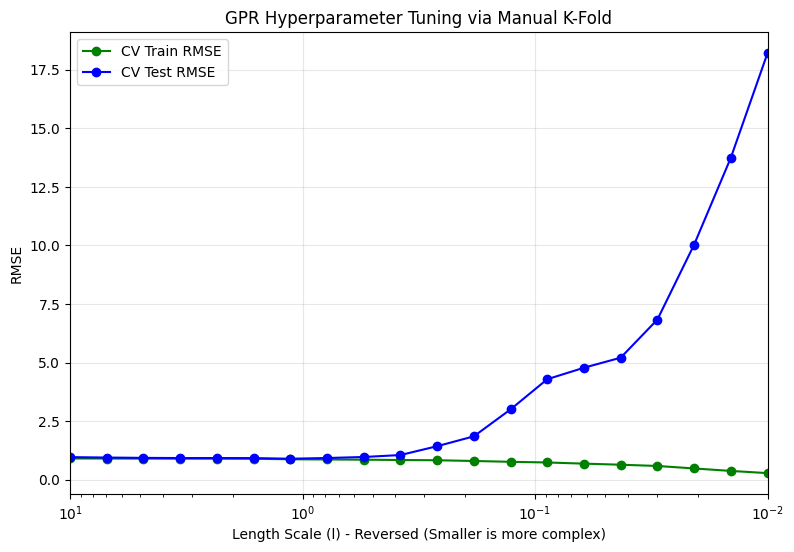

In [43]:
# Error curvers 
plt.figure(figsize=(9, 6))
plt.plot(length_scale_range, rmse_train_cv, 'g-o', label='CV Train RMSE')
plt.plot(length_scale_range, rmse_test_cv, 'b-o', label='CV Test RMSE')
plt.xscale('log')
plt.xlim(max(length_scale_range), min(length_scale_range)) 
plt.xlabel('Length Scale (l) - Reversed (Smaller is more complex)')
plt.ylabel('RMSE')
plt.title('GPR Hyperparameter Tuning via Manual K-Fold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

RBF                 : LML = -108.54
Matern (v=1.5)      : LML = -109.38
Matern (v=2.5)      : LML = -108.96


/Users/tommasogrisetti/Desktop/università/Magistrale/Astrostatistic and Machine Learning/astrostatistics_bicocca_2025-main/.venv/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Rational Quadratic  : LML = -108.54


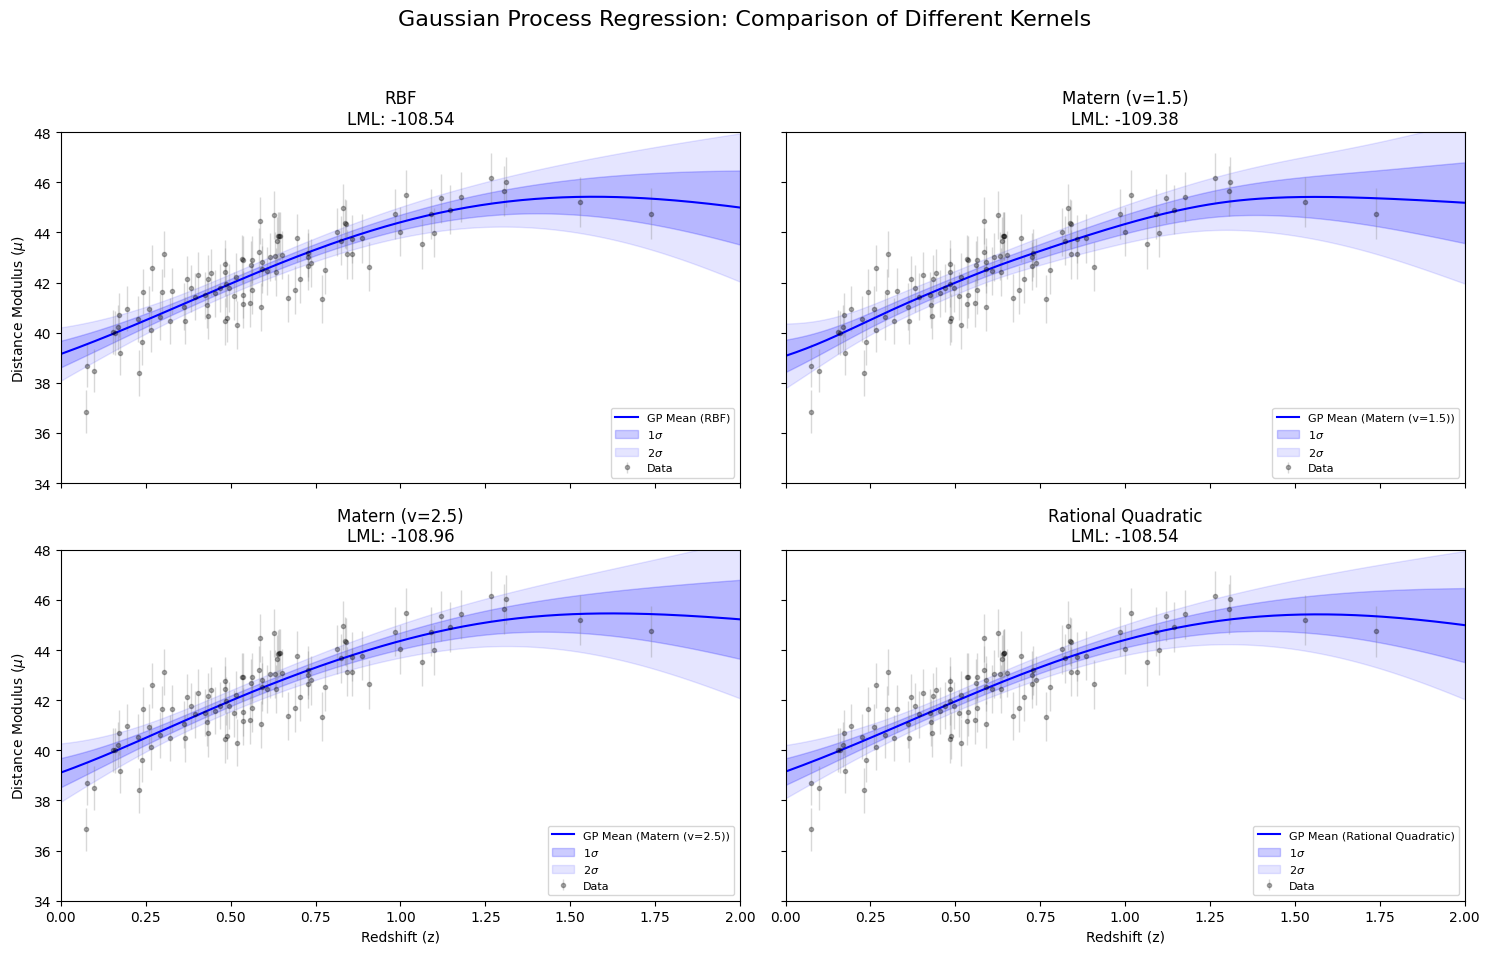

Best kernel based on LML: RBF


In [44]:
#Explorre different kernels

# Define a dense grid for plotting the smooth curves
z_fit = np.linspace(0, 2, 200).reshape(-1, 1)

kernels_to_test = {
    "RBF": ConstantKernel(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2)),
    "Matern (v=1.5)": ConstantKernel(1.0, (1e-3, 1e3)) * Matern(10, (1e-2, 1e2), nu=1.5),
    "Matern (v=2.5)": ConstantKernel(1.0, (1e-3, 1e3)) * Matern(10, (1e-2, 1e2), nu=2.5),
    "Rational Quadratic": ConstantKernel(1.0, (1e-3, 1e3)) * RationalQuadratic(length_scale=1.0, alpha=1.0)
}

best_lml = -np.inf
best_kernel_name = None
best_gp = None

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True, sharey=True)
axes = axes.flatten()

# Loop through each kernel
for i, (name, kernel) in enumerate(kernels_to_test.items()):
    ax = axes[i]
    

    gp = GaussianProcessRegressor(kernel=kernel, alpha=dY**2, n_restarts_optimizer=10, normalize_y=True)
    gp.fit(X, Y)
    

    y_pred, sigma = gp.predict(z_fit, return_std=True)
    
 
    lml_score = gp.log_marginal_likelihood_value_
    print(f"{name:20s}: LML = {lml_score:.2f}")
    
    # Track the best model
    if lml_score > best_lml:
        best_lml = lml_score
        best_kernel_name = name
        best_gp = gp
    
    # Plot
    ax.errorbar(X.ravel(), Y, dY, fmt='.k', ecolor='gray', lw=1, alpha=0.3, label='Data')
    ax.plot(z_fit, y_pred, color='blue', label=f'GP Mean ({name})')
    ax.fill_between(z_fit.ravel(), y_pred - sigma, y_pred + sigma, color='blue', alpha=0.2, label='1$\sigma$')
    ax.fill_between(z_fit.ravel(), y_pred - 2*sigma, y_pred + 2*sigma, color='blue', alpha=0.1, label='2$\sigma$')
    
    ax.set_title(f"{name}\nLML: {lml_score:.2f}")
    ax.set_xlim(0, 2)
    ax.set_ylim(34, 48)
    ax.legend(loc='lower right', fontsize=8)
    if i >= 2: ax.set_xlabel("Redshift (z)")
    if i % 2 == 0: ax.set_ylabel(r"Distance Modulus ($\mu$)")

plt.suptitle("Gaussian Process Regression: Comparison of Different Kernels", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"Best kernel based on LML: {best_kernel_name}")

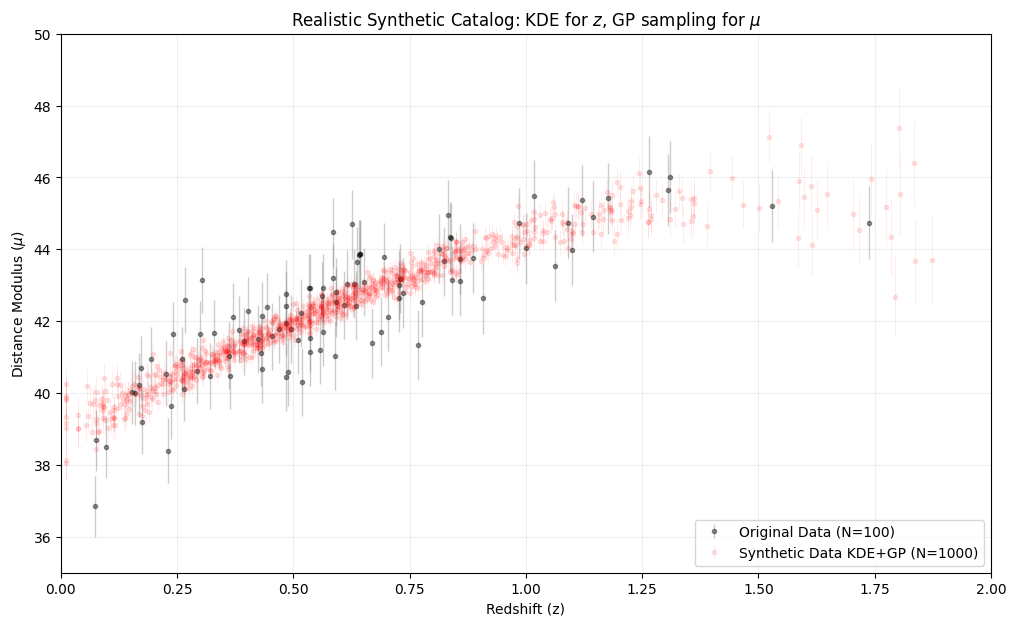

In [45]:
# Generate the new samples using GPR

N = len(z_sample) * 10
z_values = np.array(z_sample).reshape(-1, 1)
kde = KernelDensity(kernel='gaussian', bandwidth=0.1).fit(z_values)
# Sample new z values from the KDE between 0 and 2
z_generated = kde.sample(N)
z_generated = np.clip(z_generated, 0.01, 2) # Ensure the generated z values are within the range [0, 2]

kernel = RBF(10, (1e-2, 1e2)) * ConstantKernel(1, (1e-3, 1e3))
gp_RBF = GaussianProcessRegressor(kernel=kernel, alpha=dY**2, normalize_y=True, n_restarts_optimizer=5)
gp_RBF.fit(X, Y)

mu_fit, std_fit = gp_RBF.predict(z_generated, return_std=True)

# Add observational noise to the new samples to make them more realistic
generated_noise = np.random.normal(loc=0.0, scale=std_fit)
mu_generated_noisy = mu_fit + generated_noise

# Plotting the results
plt.figure(figsize=(12, 7))

# Plot Original Data (Black)
plt.errorbar(z_sample.flatten(), mu_sample.flatten(), yerr=dmu.flatten(), 
             fmt='.k', ecolor='gray', lw=1, alpha=0.4, 
             label=f'Original Data (N={len(z_sample)})')

# Plot Synthetic Data (Red)
plt.errorbar(z_generated.flatten(), mu_generated_noisy, yerr=std_fit.flatten(), 
             fmt='.', color='red', ecolor='red', lw=0.5, alpha=0.1, 
             label=f'Synthetic Data KDE+GP (N={N})')

# Formatting
plt.xlabel("Redshift (z)")
plt.ylabel(r"Distance Modulus ($\mu$)")
plt.title("Realistic Synthetic Catalog: KDE for $z$, GP sampling for $\mu$")
plt.legend(loc='lower right')
plt.xlim(0, 2)
plt.ylim(35, 50)
plt.grid(alpha=0.2)
plt.show()



SUPERNOVA DISTANCES AND REDSHIFT (PART 3)

In [ ]:
# setup and MCMC sampling to find the best fit parameters for the LCDM model using the data

# This was around 2 times slower than the second approache using astropy cosmology

# Use LCDM model relation between z and mu (using numerical integration)
#def distance_modulus_single(z, H0, Om):
    #c = 299792.458 
    #integrand = lambda zp: 1.0 / np.sqrt(Om * (1 + zp)**3 + (1 - Om))
    #integral, _ = quad(integrand, 0, z)
    #dL_pc = (c / H0) * (1 + z) * integral * 1e6
    #return 5 * np.log10(dL_pc / 10)

# Vectorize the function so it can handle the whole data array at once
#v_distance_modulus = np.vectorize(distance_modulus_single, otypes=[float])

#def Log_Likelihood(theta, z_data, mu_data, dmu_data):

    #H0, Om = theta
    
    # Calculate model for all z at once
    #model_mu = v_distance_modulus(z_data, H0, Om)

    #if np.any(np.isnan(model_mu)) or np.any(np.isinf(model_mu)):
        #return -np.inf
    
    #chi2 = np.sum(((mu_data - model_mu) / dmu_data) ** 2)
    
    #If the sum is NaN, reject it
    #if np.isnan(chi2):
        #return -np.inf
        
    #return -0.5 * chi2

def Log_Likelihood(theta, z_data, mu_data, dmu_data):
    
    H0, Om = theta
    
    cosmo = FlatLambdaCDM(H0=H0, Om0=Om, Tcmb0=2.725)
    
    # compute the model distance modulus for all z in the data using the cosmology
    model_mu = cosmo.distmod(z_data).value

    chi2 = np.sum(((mu_data - model_mu) / dmu_data) ** 2)

    if np.isnan(chi2) or np.isinf(chi2):
        return -np.inf
        
    return -0.5 * chi2


def Log_Prior(theta):
    H0, Om = theta
    # Broad physical priors
    if (50 < H0 < 100) and (0.0 < Om < 1.0):
        return 0.0
    return -np.inf

def Log_Posterior(theta, z_data, mu_data, dmu_data):
    lp = Log_Prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + Log_Likelihood(theta, z_data, mu_data, dmu_data)



In [101]:
# Set the MCMC sampler parameters
ndim = 2  # number of parameters in the model
nwalkers = 5 # number of MCMC walkers
nsteps = 10000  # number of MCMC steps to take

# each walker needs a starting point in the parameter space, so we need to create an array of shape (nwalkers, ndim) that contains the starting points for each walker.

starting_guesses = np.zeros((nwalkers, ndim))
# Set the initial guess for the parameters of the model. We can use prior knowledge about the parameters to set the initial guess, or we can use random values within a reasonable range.
for i in range(nwalkers):
    starting_guesses[i] = [
        np.random.uniform(50, 100),  # H0
        np.random.uniform(0, 1),      # Om                             
    ]

theta = np.zeros((ndim,))

H0_quick = 50
Om_quick = 0.5

theta_quick = np.array([H0_quick, Om_quick])
starting_guesses = theta_quick + 1e-1 * np.random.randn(nwalkers, ndim)
sampler = emcee.EnsembleSampler(nwalkers, ndim, Log_Posterior, args=[z_sample.flatten(), mu_sample.flatten(), dmu.flatten()])
sampler.run_mcmc(starting_guesses, nsteps, progress=True)

100%|██████████| 10000/10000 [02:04<00:00, 80.29it/s]


State([[6.56461064e+01 3.72705571e-01]
 [8.00950069e+01 3.52548754e-02]
 [7.69018400e+01 1.23350671e-01]
 [7.15032955e+01 3.45280181e-01]
 [7.06673655e+01 4.72846311e-01]], log_prob=[-46.67679694 -47.41737917 -46.87486857 -46.86830019 -47.84895603], blobs=None, random_state=('MT19937', array([2431003799,  240108077, 1630694918, 2101895136,  195225664,
       2009353047, 2955536782, 2518359162, 1891563187,  670753294,
       3185517538,  305849370, 1808202030, 1541735913, 1296201208,
       1758886330, 1741412989, 3774368339, 2409299600, 2224223352,
       1443789845, 1811826015, 2569923714, 4040195055, 1832652435,
        702796480, 3465003153,   13809149, 4147533156, 3216115295,
       3711696827, 1568433257, 1030781084,  351312737, 2109490693,
       2022984941, 3365014107, 2516130105, 1250939343, 2429032603,
       2711124741,  300669497, 3007919676, 2262688789, 3426769258,
       4027856991,   25090244, 3840837286, 1446056441, 2753018053,
       3704513114, 3619902890,  131314126, 

In [102]:
# remoeve burn-in and thin the chains
burn_in = 100
tau = sampler.get_autocorr_time()
emcee_trace = sampler.get_chain(discard=burn_in, thin=int(max(tau)), flat=True)


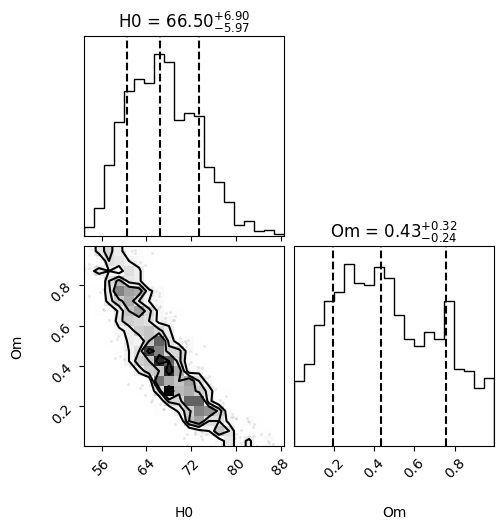

In [103]:
# Corner plot of the posterior distribution of the parameters of the model
# show also the  68% in red and 95% in blue credible intervals for each parameter in the corner plot
fig = corner.corner(emcee_trace, labels=["H0", "Om"], show_titles=True, title_fmt=".2f", quantiles=[0.16, 0.5, 0.84], title_kwargs={"fontsize": 12})
plt.show()  

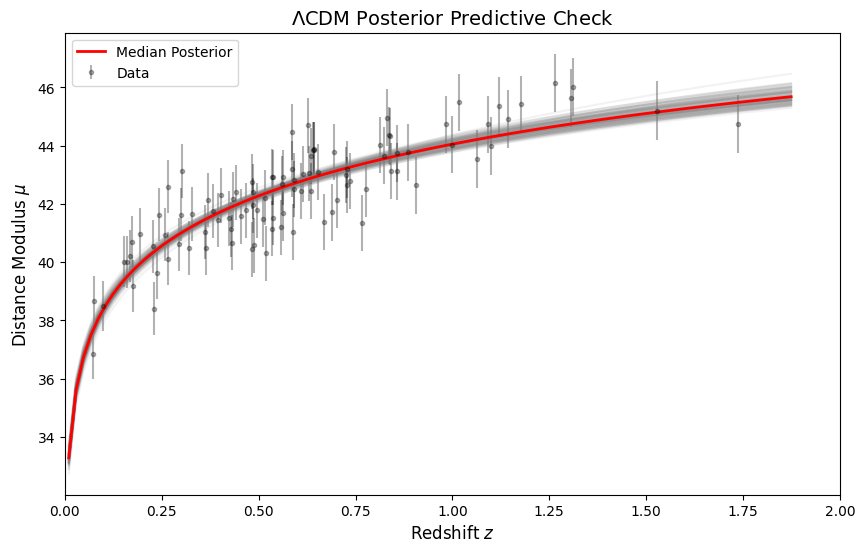

In [108]:
# 100 random samples from the posterior distribution of the parameters of the model and plot the corresponding lines in the z-mu plane to see how well the model fits the data.
plt.figure(figsize=(10,6))


plt.errorbar(z_sample.flatten(), mu_sample.flatten(), yerr=dmu.flatten(), 
             fmt='.k', alpha=0.3, label='Data')

z_fit = np.linspace(0.01, np.max(z_generated), 100)

for i in range(100):
    
    idx = np.random.randint(len(emcee_trace))
    H0_sample, Om_sample = emcee_trace[idx]
    
    
    cosmo_sample = FlatLambdaCDM(H0=H0_sample, Om0=Om_sample, Tcmb0=2.725)
    model_mu = cosmo_sample.distmod(z_fit).value
    
    
    plt.plot(z_fit, model_mu, color='gray', alpha=0.1)

H0_med, Om_med = np.median(emcee_trace, axis=0)
cosmo_med = FlatLambdaCDM(H0=H0_med, Om0=Om_med, Tcmb0=2.725)
plt.plot(z_fit, cosmo_med.distmod(z_fit).value, color='red', lw=2, label='Median Posterior')

plt.xlabel("Redshift $z$", fontsize=12)
plt.ylabel("Distance Modulus $\mu$", fontsize=12)
plt.title("$\Lambda$CDM Posterior Predictive Check", fontsize=14)
plt.legend()
plt.xlim(0, 2)
plt.show()


In [81]:
# Now we want to compare the previous model with the one without dark energy, i.e. with 0m=0
# Use dynesty to do the model comparison and find the best fit parameters for the model without dark energy. Then plot the two models together in the z-mu plane to see which one fits better the data.

# Log_Prior with a Prior Transform
def prior_transform(u):

    theta = np.zeros_like(u)
    
    # H0 prior: Uniform between 35 and 95
    theta[0] = 35.0 + u[0] * (95.0 - 35.0) 
    
    # Om prior: Uniform between 0.0 and 1.0
    theta[1] = 0.0 + u[1] * (1.0 - 0.0)
    
    return theta


def Log_Likelihood_NoDE(theta, z_data, mu_data, dmu_data):
    # theta only contains H0 as parameter
    H0 = theta[0] 
    
    # Om is strictly 1.0 (No Dark Energy)
    cosmo = FlatLambdaCDM(H0=H0, Om0=1.0, Tcmb0=2.725)
    model_mu = cosmo.distmod(z_data).value
    chi2 = np.sum(((mu_data - model_mu) / dmu_data) ** 2)

    if np.isnan(chi2) or np.isinf(chi2):
        return -np.inf
    return -0.5 * chi2


# Log_Prior with a Prior Transform
def prior_transform_NoDE(u):

    theta = np.zeros_like(u)
    
    # H0 prior: Uniform between 35 and 95
    theta[0] = 35.0 + u[0] * (95.0 - 35.0) 
    
    return theta


In [64]:
# Running the nested sampler for the 1 model (as before)
ndim = 2

sampler = dynesty.NestedSampler(
    Log_Likelihood, 
    prior_transform, 
    ndim, 
    logl_args=(z_sample, mu_sample, dmu),
    nlive=500 
)


sampler.run_nested()

results = sampler.results

logZ = results.logz[-1]
logZ_err = results.logzerr[-1]

print(f"Log Evidence (ln Z): {logZ:.2f} +/- {logZ_err:.2f}")

1633it [00:37, 43.51it/s, +500 | bound: 0 | nc: 1 | ncall: 13528 | eff(%): 16.372 | loglstar:   -inf < -46.386 <    inf | logz: -48.792 +/-  0.046 | dlogz:  0.001 >  0.509]

Log Evidence (ln Z): -48.79 +/- 0.12


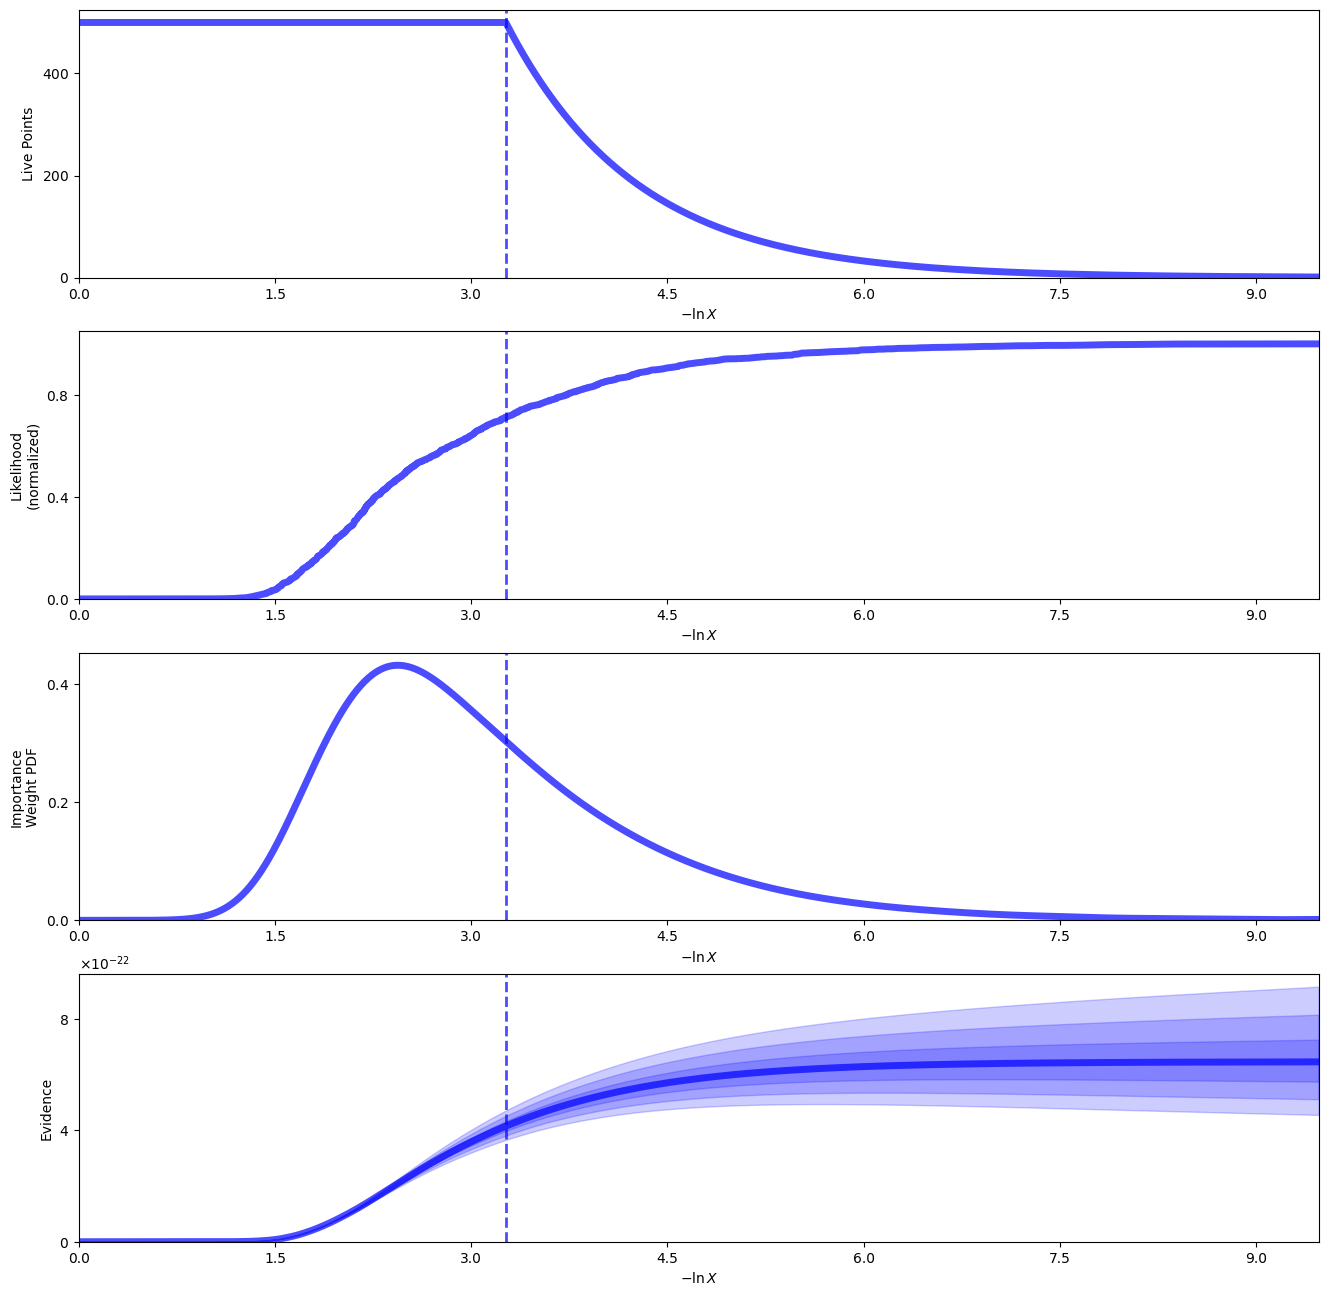

In [65]:
rfig, raxes = dyplot.runplot(results)

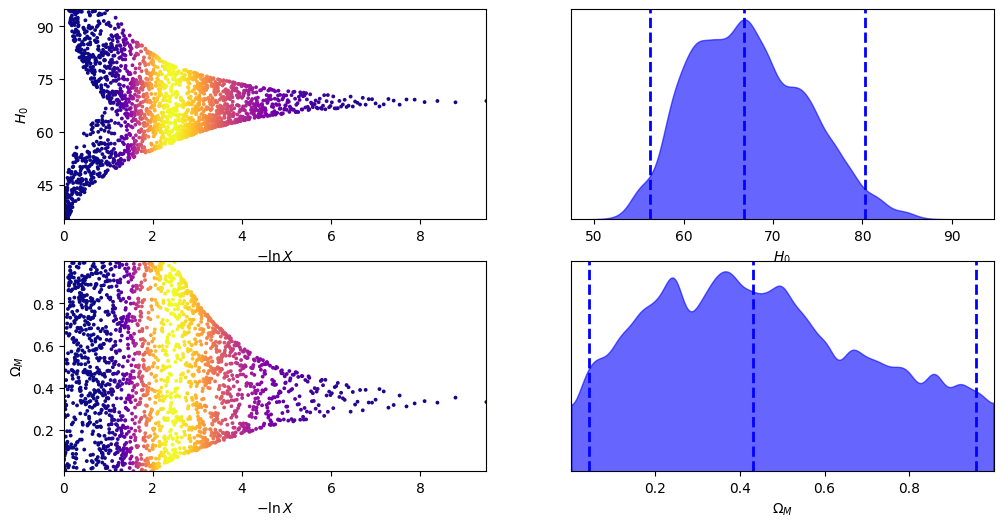

In [66]:
labels = [r'$H_0$', r'$\Omega_M$']
tfig, taxes = dyplot.traceplot(results, labels=labels)

/var/folders/hp/qdf763l9043ccrj3b3jqhqz80000gn/T/ipykernel_59761/1183523217.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


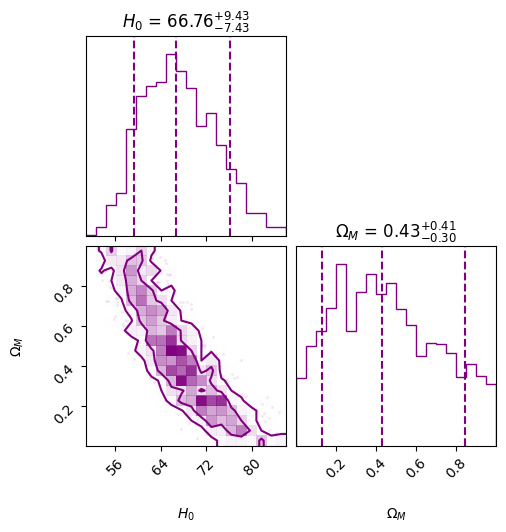

In [70]:
samples = results.samples  
weights = np.exp(results.logwt - results.logz[-1])

samples_equal = dyfunc.resample_equal(samples, weights)

fig = corner.corner(
    samples_equal,                      
    labels=labels,                        
    quantiles=[0.10, 0.5, 0.90],           
    show_titles=True,                      
    title_fmt=".2f",                       
    levels=(0.68, 0.95),                  
    plot_density=True,                                       
    color='purple'                           
)

fig.show()

In [84]:
# Running the nested sampler for the 2 model NoDE
ndim = 1

sampler_NoDE = dynesty.NestedSampler(
    Log_Likelihood_NoDE, 
    prior_transform_NoDE, 
    ndim, 
    logl_args=(z_sample, mu_sample, dmu),
    nlive=500 
)


sampler_NoDE.run_nested()

results_NoDE = sampler_NoDE.results

logZ = results_NoDE.logz[-1]
logZ_err = results_NoDE.logzerr[-1]

print(f"Log Evidence No Dark Energy (ln Z): {logZ:.2f} +/- {logZ_err:.2f}")

1586it [00:31, 50.34it/s, +500 | bound: 0 | nc: 1 | ncall: 12355 | eff(%): 17.596 | loglstar:   -inf < -47.103 <    inf | logz: -49.370 +/-  0.038 | dlogz:  0.001 >  0.509]

Log Evidence No Dark Energy (ln Z): -49.37 +/- 0.11


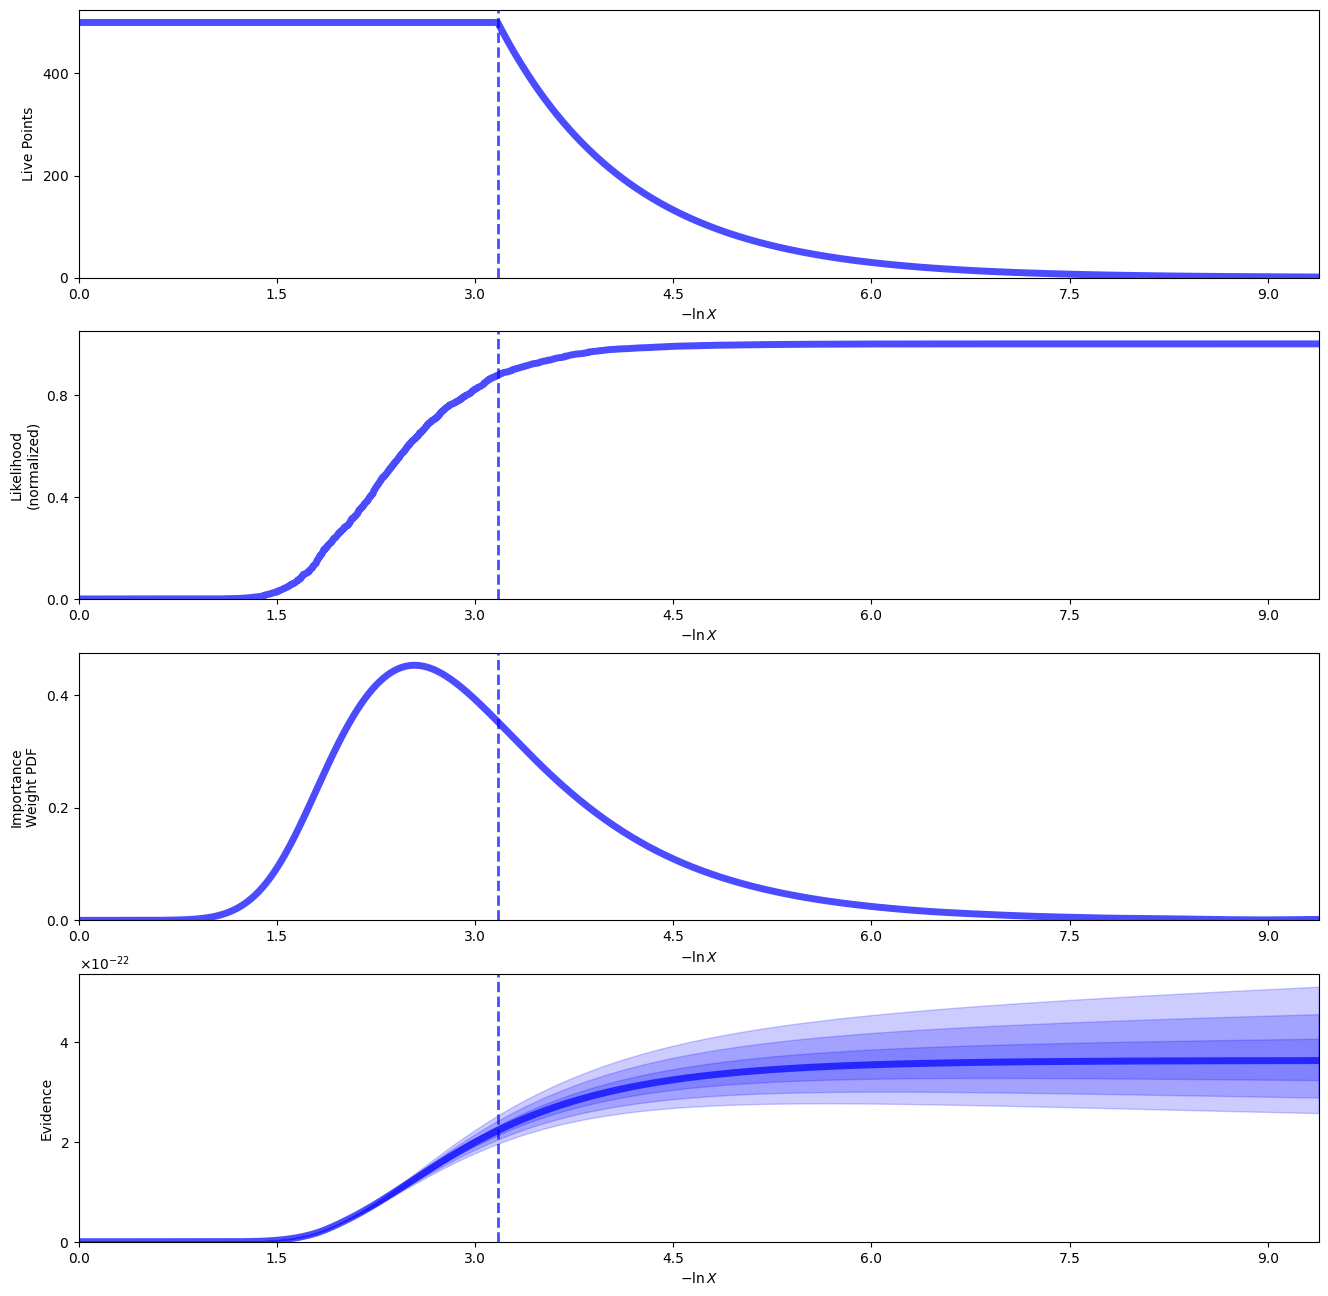

In [85]:
rfig, raxes = dyplot.runplot(results_NoDE)

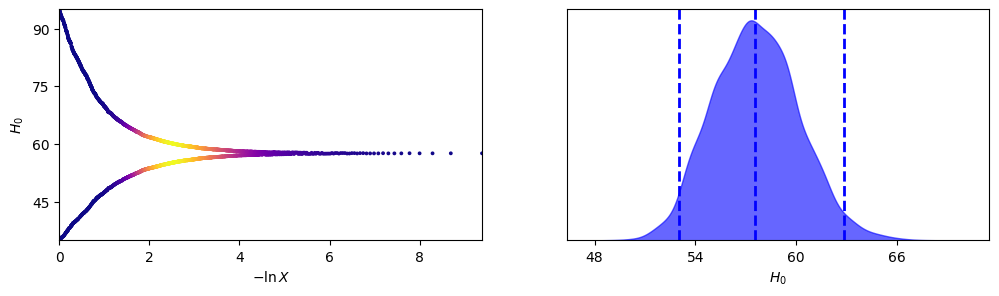

In [88]:
labels = [r'$H_0$', r'$\Omega_M$']
tfig, taxes = dyplot.traceplot(results_NoDE, labels=labels)

/var/folders/hp/qdf763l9043ccrj3b3jqhqz80000gn/T/ipykernel_59761/598257678.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


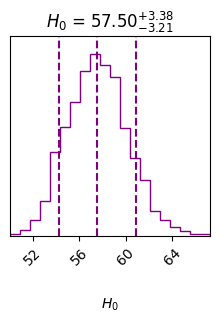

In [86]:
samples = results_NoDE.samples  
weights = np.exp(results_NoDE.logwt - results_NoDE.logz[-1])

samples_equal = dyfunc.resample_equal(samples, weights)

fig = corner.corner(
    samples_equal,                      
    labels=labels,                        
    quantiles=[0.10, 0.5, 0.90],           
    show_titles=True,                      
    title_fmt=".2f",                       
    levels=(0.68, 0.95),                  
    plot_density=True,                                       
    color='purple'                           
)

fig.show()

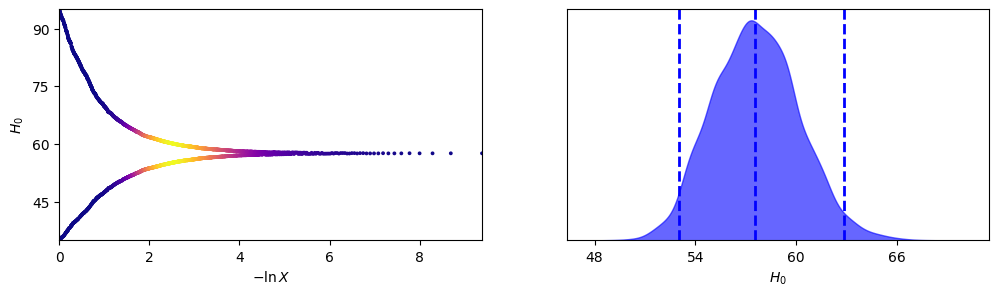

In [89]:
# Compute bayes factor
np.exp(sampler.results.logz[-1])/np.exp(sampler_NoDE.results.logz[-1])

1.780899966887158